# UHCS Micrograph Phase Identification System

**Dataset:** Ultra-High Carbon Steel (UHCS) Micrographs — Carnegie Mellon University (via Kaggle: `safi842/highcarbon-micrographs`)

**Objective:** given a new micrograph image, automatically (1) segment it into phase regions, (2) classify its dominant microconstituent, and (3) extract quantitative microstructural parameters — with no manual measurement required.

## Pipeline

| Stage | What it does | Ground truth used |
|---|---|---|
| 1. Pseudo-mask generation | Classical image processing (Otsu thresholding + morphology) proposes a phase mask for every micrograph | none — this *creates* the mask |
| 2. Verification checkpoint | Masks are saved to disk next to their source image for human review/correction before training | human judgment (optional, recommended) |
| 3. U-Net segmentation | A CNN encoder-decoder learns to reproduce (and generalize) the masks on new, unseen images | masks from stage 1/2 |
| 4. CNN classifier | A CNN predicts the *actual* labeled microconstituent class | real expert labels in `new_metadata.xlsx` |
| 5. Feature extraction | Classical image processing measures 4 quantitative parameters from the predicted mask | derived from stage 3 output |
| 6. Inference pipeline | Chains stages 3-5 into a single function for a brand-new image | - |

**Honesty note on Stage 3:** the dataset ships with only image-level labels (`primary_microconstituent`), not pixel-level segmentation masks. The U-Net therefore trains against *pseudo-masks* generated by classical thresholding, not human-annotated ground truth. Its segmentation accuracy is reported against those same pseudo-masks, so treat it as a measure of how well the network reproduces/generalizes the classical method, not as validated ground-truth segmentation accuracy. The CNN classifier (Stage 4), by contrast, trains and is evaluated against real expert labels, so its accuracy figures are fully trustworthy. This distinction is kept explicit throughout.


## 1. Environment Setup

In [1]:
import os, glob, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = 'white'

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from skimage.measure import label as sk_label, regionprops
from skimage.feature import graycomatrix, graycoprops

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR   = "./data"
IMG_DIR    = os.path.join(DATA_DIR, "For Training", "Cropped")
META_PATH  = os.path.join(DATA_DIR, "new_metadata.xlsx")
IMG_SIZE   = (128, 128)          # (width, height) fed to every model
MASK_DIR   = "./masks_pseudo"     # stage-1 output, pre-verification
MASK_VERIFIED_DIR = "./masks_verified"  # stage-2: verified masks live here once reviewed

os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(MASK_VERIFIED_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Image directory exists:", os.path.isdir(IMG_DIR))


I0000 00:00:1788766802.657025     940 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788766802.699617     940 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788766803.839847     940 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Image directory exists: True


## 2. Data Loading & Exploration

The archive contains **961 cropped micrographs**. A metadata spreadsheet (`new_metadata.xlsx`) carries expert-assigned labels for **598** of them: the primary microconstituent phase, plus the processing parameters that produced each sample (anneal temperature/time, cooling method, magnification).

In [2]:
all_paths = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
print(f"Total cropped micrographs found: {len(all_paths)}")

meta = pd.read_excel(META_PATH)
meta['num'] = meta['path'].str.extract(r'micrograph(\d+)\.png').astype(int)
meta['cropped_path'] = meta['num'].apply(lambda n: os.path.join(IMG_DIR, f"Croppedmicrograph{n}.png"))
meta = meta[meta['cropped_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"Labeled micrographs (usable): {len(meta)}")
meta.head()


Total cropped micrographs found: 961
Labeled micrographs (usable): 598


,path,anneal_temperature,anneal_time,anneal_time_unit,cool_method,magnification,primary_microconstituent,num,cropped_path
0,micrograph2.png,800,85,H,Q,1964X,spheroidite,2,./data/For Training/Cropped/Croppedmicrograph2...
1,micrograph4.png,970,90,M,FC,NaN,pearlite+spheroidite,4,./data/For Training/Cropped/Croppedmicrograph4...
2,micrograph5.png,750,5,M,Q,4910X,pearlite,5,./data/For Training/Cropped/Croppedmicrograph5...
3,micrograph6.png,970,90,M,AR,1178X,spheroidite,6,./data/For Training/Cropped/Croppedmicrograph6...
4,micrograph7.png,970,90,M,Q,982x,spheroidite+widmanstatten,7,./data/For Training/Cropped/Croppedmicrograph7...


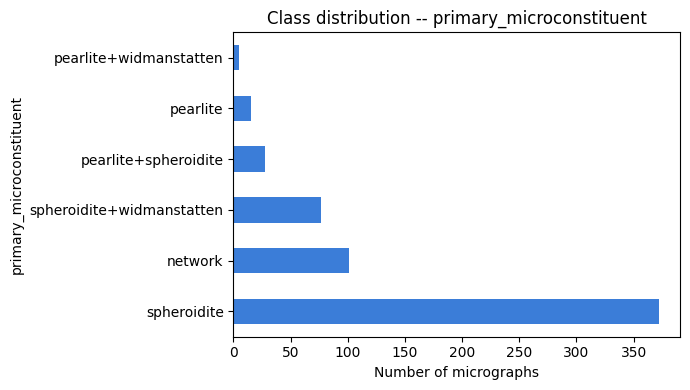

primary_microconstituent
spheroidite                  372
network                      101
spheroidite+widmanstatten     77
pearlite+spheroidite          28
pearlite                      15
pearlite+widmanstatten         5
Name: count, dtype: int64

Note the strong class imbalance (spheroidite=372 vs pearlite+widmanstatten=5).
This is carried forward honestly into the classifier's evaluation in Section 6.


In [3]:
fig, ax = plt.subplots(figsize=(7,4))
counts = meta['primary_microconstituent'].value_counts()
counts.plot(kind='barh', ax=ax, color='#3b7dd8')
ax.set_xlabel("Number of micrographs")
ax.set_title("Class distribution -- primary_microconstituent")
plt.tight_layout()
plt.show()

print(counts)
print("\nNote the strong class imbalance (spheroidite=372 vs pearlite+widmanstatten=5).")
print("This is carried forward honestly into the classifier's evaluation in Section 6.")


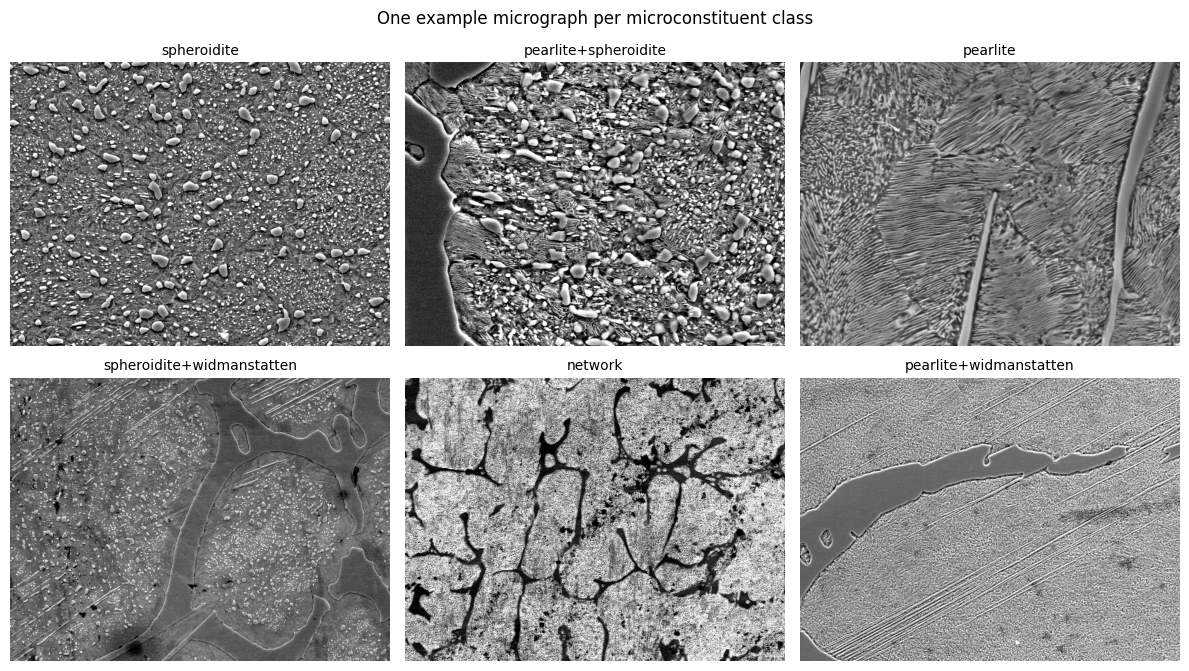

In [4]:
# Sample grid: one example micrograph per class
classes = meta['primary_microconstituent'].unique()
fig, axes = plt.subplots(2, 3, figsize=(12,7))
for ax, cls in zip(axes.ravel(), classes):
    row = meta[meta['primary_microconstituent'] == cls].iloc[0]
    img = cv2.imread(row['cropped_path'], cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
for ax in axes.ravel()[len(classes):]:
    ax.axis('off')
plt.suptitle("One example micrograph per microconstituent class")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing\n\nEvery micrograph is grayscale (stored redundantly as RGB), resized to a fixed 128x128 and scaled to `[0,1]`. Loading the full set into memory at this resolution is cheap (~60 MB) and keeps every downstream stage fast.

In [5]:
def load_gray(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

t0 = time.time()
all_names = [os.path.basename(p) for p in all_paths]
all_imgs  = np.stack([load_gray(p) for p in all_paths]).astype('float32') / 255.0
print(f"Loaded {len(all_imgs)} images -> array {all_imgs.shape} in {time.time()-t0:.1f}s")


Loaded 961 images -> array (961, 128, 128) in 7.3s


## 4. Stage 1 -- Pseudo-Mask Generation (Classical Image Processing)

No pixel-level annotations exist for this dataset, so a phase mask is proposed for **every** micrograph using:

1. Gaussian blur (noise suppression)
2. **Otsu's method** -- automatic global thresholding that separates the two dominant phase populations by intensity
3. Morphological opening + closing -- removes speckle noise and fills small holes

This is deliberately simple and deterministic, which is what makes Stage 2 (human verification) practical -- reviewers know exactly what logic produced each mask.

In [6]:
def generate_pseudo_mask(gray_uint8):
    blur = cv2.GaussianBlur(gray_uint8, (5,5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return (mask > 0).astype('uint8')

t0 = time.time()
all_masks = np.zeros_like(all_imgs, dtype='float32')
for i in range(len(all_imgs)):
    g = (all_imgs[i]*255).astype('uint8')
    m = generate_pseudo_mask(g)
    all_masks[i] = m.astype('float32')
    cv2.imwrite(os.path.join(MASK_DIR, all_names[i]), (m*255).astype('uint8'))

print(f"Generated {len(all_masks)} pseudo-masks in {time.time()-t0:.2f}s -> saved to '{MASK_DIR}/'")
print(f"Mean foreground fraction across dataset: {all_masks.mean():.3f}")


Generated 961 pseudo-masks in 0.29s -> saved to './masks_pseudo/'
Mean foreground fraction across dataset: 0.536


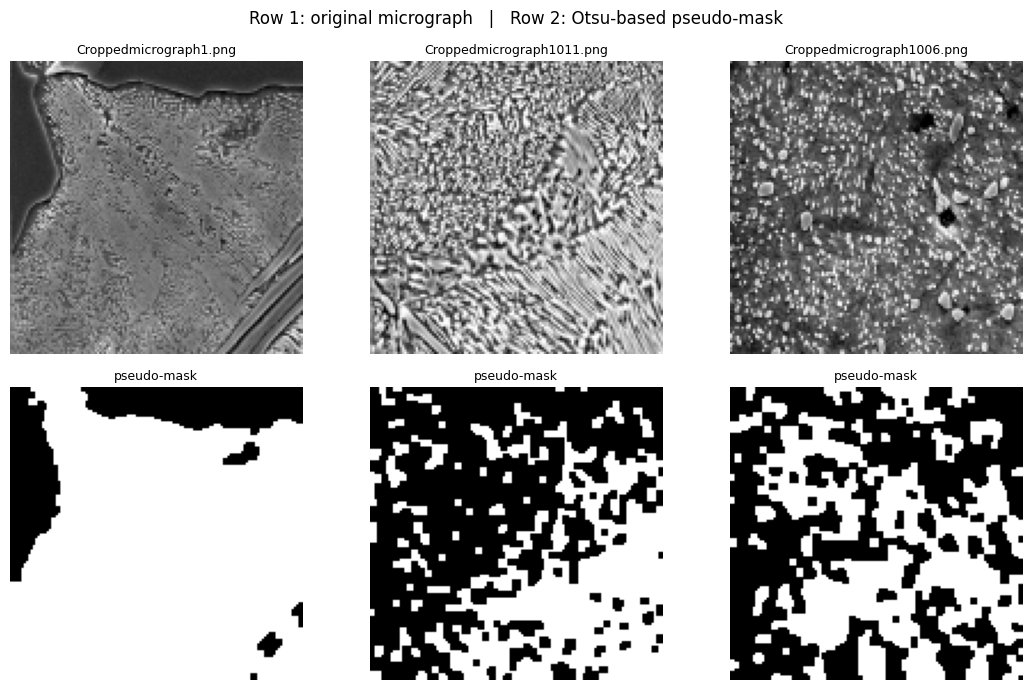

In [7]:
# Visual sanity check: original vs pseudo-mask, for a few different classes
sample_idx = [0, 9, 5]  # a mix of structures
fig, axes = plt.subplots(2, 3, figsize=(11,7))
for col, idx in enumerate(sample_idx):
    axes[0, col].imshow(all_imgs[idx], cmap='gray'); axes[0, col].set_title(all_names[idx], fontsize=9); axes[0, col].axis('off')
    axes[1, col].imshow(all_masks[idx], cmap='gray'); axes[1, col].set_title('pseudo-mask', fontsize=9); axes[1, col].axis('off')
plt.suptitle("Row 1: original micrograph   |   Row 2: Otsu-based pseudo-mask")
plt.tight_layout()
plt.show()


## 5. Stage 2 -- Human Verification Checkpoint

This stage is intentionally **decoupled** from model training so masking and modeling never get tangled together:

- Stage 1 wrote every pseudo-mask as a plain PNG into `./masks_pseudo/`, named identically to its source image.
- To verify/correct a mask: open the image and its mask side by side (the helper below builds that comparison), edit the mask in any image editor (paint over wrong regions), and save the corrected file into `./masks_verified/` under the **same filename**.
- The loader below is the only thing Stage 3 (U-Net) ever calls. It automatically prefers a verified mask when one exists for a given filename, and silently falls back to the Stage-1 pseudo-mask otherwise.
- This means: verify 10 masks today, verify 50 more next week -- the U-Net benefits automatically on the next training run, with zero changes to any modeling code.

In [8]:
def load_training_mask(filename, size=IMG_SIZE):
    verified_path = os.path.join(MASK_VERIFIED_DIR, filename)
    pseudo_path   = os.path.join(MASK_DIR, filename)
    path = verified_path if os.path.exists(verified_path) else pseudo_path
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    m = cv2.resize(m, size, interpolation=cv2.INTER_NEAREST)
    return (m > 127).astype('float32')

def build_review_pair(filename, out_dir="./mask_review"):
    # Writes a side-by-side [original | mask] PNG for quick human review.
    os.makedirs(out_dir, exist_ok=True)
    img = cv2.imread(os.path.join(IMG_DIR, filename), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    mask = load_training_mask(filename)
    pair = np.hstack([img, (mask*255).astype('uint8')])
    cv2.imwrite(os.path.join(out_dir, f"review_{filename}"), pair)
    return pair

# Demonstrate the review workflow on a handful of samples
for name in all_names[:4]:
    build_review_pair(name)

n_verified = len([f for f in os.listdir(MASK_VERIFIED_DIR) if f.endswith('.png')])
print(f"Verified masks currently available: {n_verified} (0 = none reviewed yet, using pseudo-masks for all)")
print("Example review pairs written to ./mask_review/ for the first 4 images.")


Verified masks currently available: 0 (0 = none reviewed yet, using pseudo-masks for all)
Example review pairs written to ./mask_review/ for the first 4 images.


## 6. Stage 3 -- U-Net Segmentation Model

Standard U-Net: a convolutional encoder that downsamples through 3 stages, a bottleneck, and a decoder that upsamples back up, with **skip connections** carrying fine spatial detail directly from encoder to decoder at matching resolutions. No attention/transformer components -- segmentation at this dataset size is a convolution-favoring problem (see discussion earlier in this project).

In [9]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def build_unet(input_shape=(128,128,1), base=12):
    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, base);    p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, base*2);      p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, base*4);      p3 = layers.MaxPooling2D()(c3)
    b  = conv_block(p3, base*8)                                          # bottleneck

    u3 = layers.Conv2DTranspose(base*4, 2, strides=2, padding='same')(b)
    u3 = layers.Concatenate()([u3, c3]);  c4 = conv_block(u3, base*4)    # skip connection 3
    u2 = layers.Conv2DTranspose(base*2, 2, strides=2, padding='same')(c4)
    u2 = layers.Concatenate()([u2, c2]);  c5 = conv_block(u2, base*2)    # skip connection 2
    u1 = layers.Conv2DTranspose(base, 2, strides=2, padding='same')(c5)
    u1 = layers.Concatenate()([u1, c1]);  c6 = conv_block(u1, base)      # skip connection 1

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)
    return models.Model(inputs, outputs, name="UNet_phase_segmentation")

def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1]); y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)

unet = build_unet()
unet.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=bce_dice_loss, metrics=[dice_coef, 'accuracy'])
unet.summary()


Model: "UNet_phase_segmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        120 │ input_layer[0][0] │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         48 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      1,308 │ batch_normalizat… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         48 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      2,616 │ max_pooling2d[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         96 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      5,208 │ batch_normalizat… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     10,416 │ max_pooling2d_1[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        192 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     20,784 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     41,568 │ max_pooling2d_2[

 Total params: 273,277 (1.04 MB)

 Trainable params: 272,221 (1.04 MB)

 Non-trainable params: 1,056 (4.12 KB)

In [10]:
X_seg = all_imgs[..., None]
y_seg = np.stack([load_training_mask(n) for n in all_names])[..., None]

Xs_tr, Xs_val, ys_tr, ys_val = train_test_split(X_seg, y_seg, test_size=0.2, random_state=SEED)
print(f"U-Net train/val split: {Xs_tr.shape[0]} / {Xs_val.shape[0]} images")

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]

t0 = time.time()
history_unet = unet.fit(
    Xs_tr, ys_tr,
    validation_data=(Xs_val, ys_val),
    batch_size=16, epochs=10, callbacks=cb, verbose=2
)
print(f"U-Net training finished in {time.time()-t0:.1f}s")


U-Net train/val split: 768 / 193 images


Epoch 1/10


48/48 - 37s - 781ms/step - accuracy: 0.7436 - dice_coef: 0.6942 - loss: 0.8162 - val_accuracy: 0.5197 - val_dice_coef: 0.6282 - val_loss: 1.1718 - learning_rate: 0.0010


Epoch 2/10


48/48 - 39s - 823ms/step - accuracy: 0.8145 - dice_coef: 0.7777 - loss: 0.6326 - val_accuracy: 0.5197 - val_dice_coef: 0.6782 - val_loss: 1.4431 - learning_rate: 0.0010


...

Epoch 9/10


48/48 - 42s - 867ms/step - accuracy: 0.8671 - dice_coef: 0.8406 - loss: 0.4622 - val_accuracy: 0.8370 - val_dice_coef: 0.8124 - val_loss: 0.5599 - learning_rate: 5.0000e-04


Epoch 10/10


48/48 - 41s - 848ms/step - accuracy: 0.8707 - dice_coef: 0.8451 - loss: 0.4510 - val_accuracy: 0.8531 - val_dice_coef: 0.8222 - val_loss: 0.5099 - learning_rate: 5.0000e-04


U-Net training finished in 417.5s


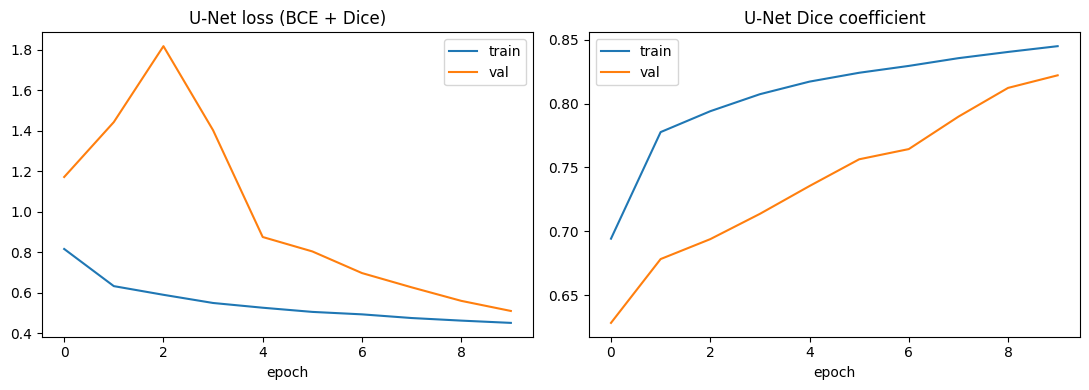

In [11]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].plot(history_unet.history['loss'], label='train')
axes[0].plot(history_unet.history['val_loss'], label='val')
axes[0].set_title('U-Net loss (BCE + Dice)'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history_unet.history['dice_coef'], label='train')
axes[1].plot(history_unet.history['val_dice_coef'], label='val')
axes[1].set_title('U-Net Dice coefficient'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


**Reading these numbers honestly:** Dice/IoU below are computed against the *pseudo-masks from Stage 1/2* -- the only ground truth this dataset provides. A high score means the U-Net has successfully learned to reproduce and generalize the classical thresholding rule to new images (which is genuinely useful -- it replaces a manual thresholding step with a single forward pass). It is **not** a validated measurement of true phase-boundary accuracy, since no independently human-annotated mask exists to check against. That gap closes automatically as more masks move from `masks_pseudo/` to `masks_verified/` in Stage 2.

In [12]:
def iou_score(y_true, y_pred, thresh=0.5):
    y_pred_bin = (y_pred > thresh).astype('float32')
    intersection = (y_true * y_pred_bin).sum(axis=(1,2,3))
    union = ((y_true + y_pred_bin) > 0).sum(axis=(1,2,3))
    return np.where(union==0, 1.0, intersection/np.maximum(union,1e-7))

val_pred = unet.predict(Xs_val, verbose=0)
val_iou  = iou_score(ys_val, val_pred)
val_dice = (2*(ys_val*(val_pred>0.5)).sum(axis=(1,2,3)) + 1) / (ys_val.sum(axis=(1,2,3)) + (val_pred>0.5).sum(axis=(1,2,3)) + 1)

print("U-Net validation performance (against pseudo-masks):")
print(f"  Mean IoU  : {val_iou.mean():.4f}  (std {val_iou.std():.4f})")
print(f"  Mean Dice : {val_dice.mean():.4f}  (std {val_dice.std():.4f})")
print(f"  Pixel accuracy: {history_unet.history['val_accuracy'][-1]:.4f}")


U-Net validation performance (against pseudo-masks):
  Mean IoU  : 0.7508  (std 0.1325)
  Mean Dice : 0.8504  (std 0.0967)
  Pixel accuracy: 0.8531


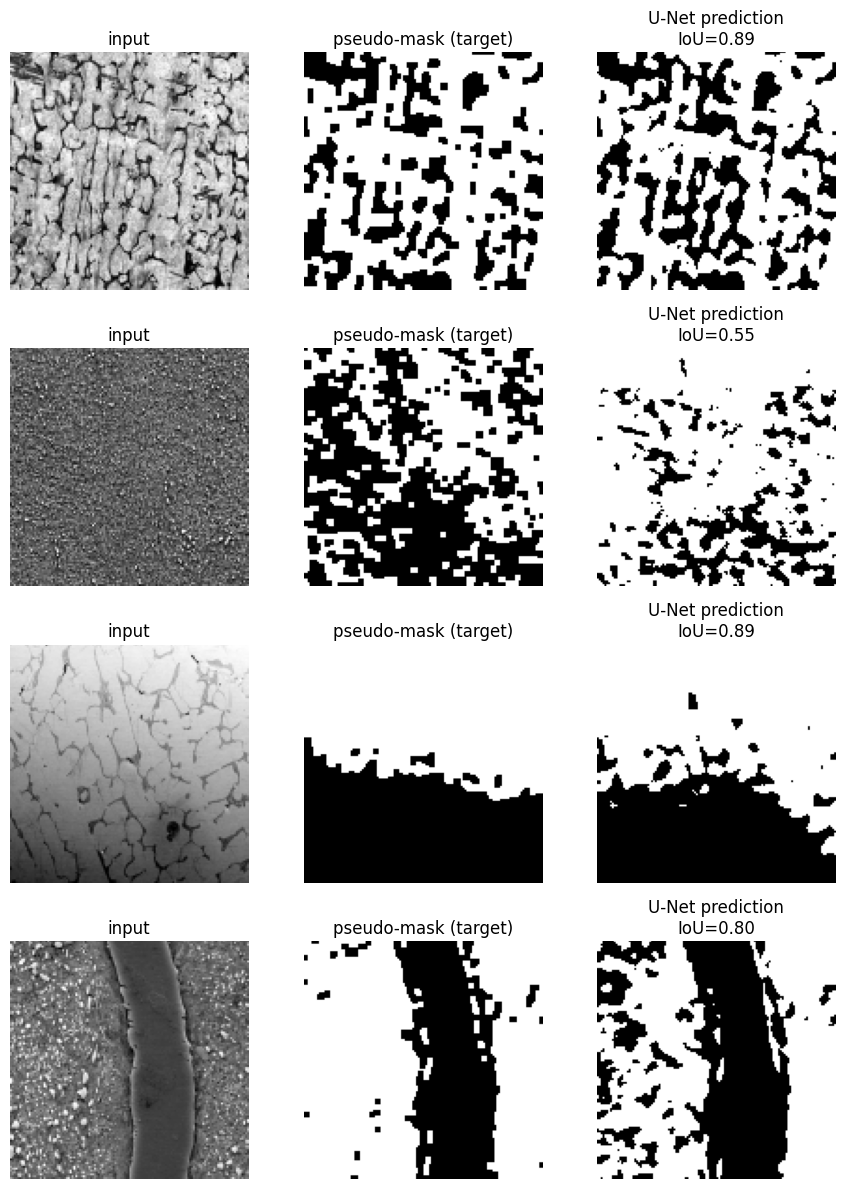

In [13]:
# Visual check: input | pseudo-mask target | U-Net prediction
n_show = 4
idxs = np.random.RandomState(SEED).choice(len(Xs_val), n_show, replace=False)
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))
for row, i in enumerate(idxs):
    axes[row,0].imshow(Xs_val[i,...,0], cmap='gray'); axes[row,0].set_title('input'); axes[row,0].axis('off')
    axes[row,1].imshow(ys_val[i,...,0], cmap='gray'); axes[row,1].set_title('pseudo-mask (target)'); axes[row,1].axis('off')
    axes[row,2].imshow(val_pred[i,...,0] > 0.5, cmap='gray'); axes[row,2].set_title(f'U-Net prediction\nIoU={val_iou[i]:.2f}'); axes[row,2].axis('off')
plt.tight_layout(); plt.show()


## 7. CNN Classifier -- Microconstituent Phase Classification

This model trains and is evaluated against the **real expert labels** in `new_metadata.xlsx` -- no pseudo-labeling involved. Given the class imbalance shown in Section 2, `class_weight` is used so the loss doesn't just learn to always predict `spheroidite`.

In [14]:
le = LabelEncoder()
meta['label_id'] = le.fit_transform(meta['primary_microconstituent'])
print("Classes:", list(le.classes_))

X_cls = np.stack([load_gray(p) for p in meta['cropped_path']]).astype('float32')/255.0
X_cls = X_cls[..., None]
y_cls = meta['label_id'].values

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls)
print(f"Classifier train/test split: {Xc_tr.shape[0]} / {Xc_te.shape[0]}")

class_weights = compute_class_weight('balanced', classes=np.unique(yc_tr), y=yc_tr)
class_weight_dict = dict(zip(np.unique(yc_tr), class_weights))
print("Class weights (balanced):", {le.classes_[k]: round(v,2) for k,v in class_weight_dict.items()})


Classes: ['network', 'pearlite', 'pearlite+spheroidite', 'pearlite+widmanstatten', 'spheroidite', 'spheroidite+widmanstatten']


Classifier train/test split: 478 / 120
Class weights (balanced): {'network': np.float64(0.98), 'pearlite': np.float64(6.64), 'pearlite+spheroidite': np.float64(3.62), 'pearlite+widmanstatten': np.float64(19.92), 'spheroidite': np.float64(0.27), 'spheroidite+widmanstatten': np.float64(1.28)}


In [15]:
def build_classifier(input_shape=(128,128,1), n_classes=6):
    inputs = layers.Input(input_shape)
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name="CNN_phase_classifier")

clf = build_classifier(n_classes=len(le.classes_))
clf.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
clf.summary()


Model: "CNN_phase_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,246 (415.02 KB)

 Trainable params: 106,022 (414.15 KB)

 Non-trainable params: 224 (896.00 B)

In [16]:
cb_clf = [
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5),
]

t0 = time.time()
history_clf = clf.fit(
    Xc_tr, yc_tr,
    validation_split=0.15,
    batch_size=16, epochs=60,
    class_weight=class_weight_dict,
    callbacks=cb_clf, verbose=2
)
print(f"Classifier training finished in {time.time()-t0:.1f}s")


Epoch 1/60


26/26 - 5s - 196ms/step - accuracy: 0.2488 - loss: 2.0283 - val_accuracy: 0.1250 - val_loss: 1.5817 - learning_rate: 0.0010


Epoch 2/60


26/26 - 5s - 190ms/step - accuracy: 0.2562 - loss: 1.9652 - val_accuracy: 0.7083 - val_loss: 1.5098 - learning_rate: 0.0010


Epoch 3/60


...

Epoch 15/60


26/26 - 5s - 194ms/step - accuracy: 0.5591 - loss: 0.8779 - val_accuracy: 0.2917 - val_loss: 1.7510 - learning_rate: 2.5000e-04


Epoch 16/60


26/26 - 5s - 196ms/step - accuracy: 0.5690 - loss: 1.0076 - val_accuracy: 0.2917 - val_loss: 1.8037 - learning_rate: 2.5000e-04


Classifier training finished in 83.7s


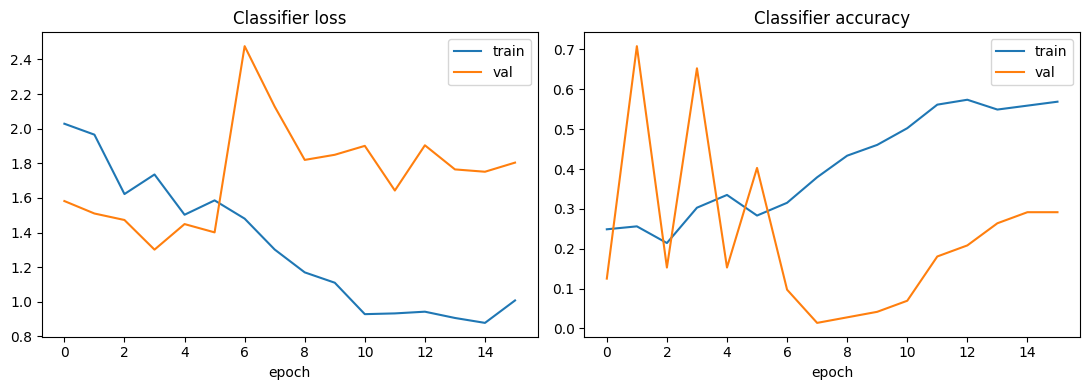

In [17]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].plot(history_clf.history['loss'], label='train')
axes[0].plot(history_clf.history['val_loss'], label='val')
axes[0].set_title('Classifier loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history_clf.history['accuracy'], label='train')
axes[1].plot(history_clf.history['val_accuracy'], label='val')
axes[1].set_title('Classifier accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


In [18]:
y_pred = clf.predict(Xc_te, verbose=0).argmax(axis=1)

test_acc = accuracy_score(yc_te, y_pred)
test_f1_macro = f1_score(yc_te, y_pred, average='macro')
test_f1_weighted = f1_score(yc_te, y_pred, average='weighted')

print(f"Test accuracy       : {test_acc:.4f}")
print(f"Test F1 (macro)      : {test_f1_macro:.4f}   <- unweighted, punishes poor performance on rare classes")
print(f"Test F1 (weighted)   : {test_f1_weighted:.4f}")
print()
print(classification_report(yc_te, y_pred, target_names=le.classes_, zero_division=0))


Test accuracy       : 0.6000
Test F1 (macro)      : 0.1544   <- unweighted, punishes poor performance on rare classes
Test F1 (weighted)   : 0.4882

                           precision    recall  f1-score   support

                  network       0.00      0.00      0.00        20
                 pearlite       0.00      0.00      0.00         3
     pearlite+spheroidite       0.00      0.00      0.00         6
   pearlite+widmanstatten       0.00      0.00      0.00         1
              spheroidite       0.62      0.93      0.74        75
spheroidite+widmanstatten       0.29      0.13      0.18        15

                 accuracy                           0.60       120
                macro avg       0.15      0.18      0.15       120
             weighted avg       0.42      0.60      0.49       120



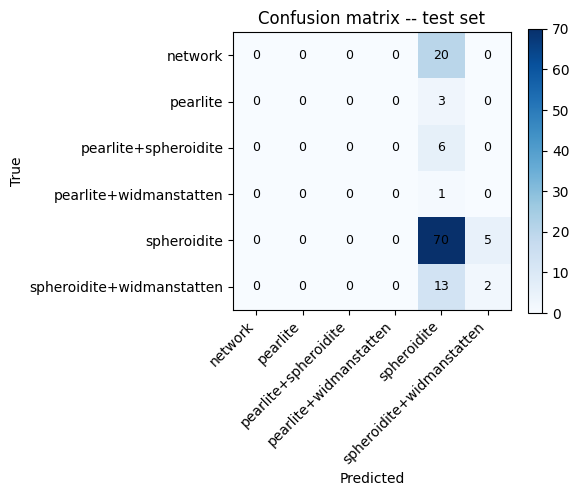

Rare classes (pearlite, pearlite+widmanstatten) have only 1-3 test examples each,
so their individual precision/recall figures above are high-variance -- reported honestly, not smoothed over.


In [19]:
cm = confusion_matrix(yc_te, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(le.classes_))); ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticks(range(len(le.classes_))); ax.set_yticklabels(le.classes_)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=9)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion matrix -- test set')
plt.colorbar(im); plt.tight_layout(); plt.show()

print("Rare classes (pearlite, pearlite+widmanstatten) have only 1-3 test examples each,")
print("so their individual precision/recall figures above are high-variance -- reported honestly, not smoothed over.")


## 8. Quantitative Feature Extraction

Four parameters, computed directly from the (U-Net or pseudo-mask) segmentation output plus the raw grayscale image:

1. **Phase area fraction** -- fraction of image pixels belonging to the segmented foreground phase
2. **Mean particle/grain equivalent diameter** -- average size of connected phase regions
3. **Particle density** -- number of distinct phase regions per unit image area
4. **GLCM contrast** -- a texture feature (gray-level co-occurrence matrix) capturing local intensity variation, independent of the segmentation

In [20]:
def extract_features(gray_uint8, mask_uint8):
    area_fraction = mask_uint8.mean()

    lbl = sk_label(mask_uint8)
    props = [p for p in regionprops(lbl) if p.area >= 3]
    sizes = [p.equivalent_diameter_area for p in props]
    mean_particle_size = float(np.mean(sizes)) if sizes else 0.0
    particle_count = len(props)
    particle_density = particle_count / mask_uint8.size

    glcm = graycomatrix(gray_uint8, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    glcm_contrast = float(graycoprops(glcm, 'contrast')[0,0])

    return {
        'phase_area_fraction': round(float(area_fraction), 4),
        'mean_particle_size_px': round(mean_particle_size, 2),
        'particle_count': particle_count,
        'particle_density': round(particle_density, 6),
        'glcm_contrast': round(glcm_contrast, 2),
    }

# Demonstrate on one sample
demo_gray = (all_imgs[0]*255).astype('uint8')
demo_mask = all_masks[0].astype('uint8')
extract_features(demo_gray, demo_mask)


{'phase_area_fraction': 0.8186,
 'mean_particle_size_px': 130.68,
 'particle_count': 1,
 'particle_density': 6.1e-05,
 'glcm_contrast': 599.22}

In [21]:
t0 = time.time()
feature_rows = []
for i, name in enumerate(all_names):
    gray = (all_imgs[i]*255).astype('uint8')
    mask = all_masks[i].astype('uint8')
    feats = extract_features(gray, mask)
    feats['filename'] = name
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)[['filename','phase_area_fraction','mean_particle_size_px','particle_count','particle_density','glcm_contrast']]
print(f"Extracted features for {len(features_df)} micrographs in {time.time()-t0:.2f}s")
features_df.head(10)


Extracted features for 961 micrographs in 1.34s


,filename,phase_area_fraction,mean_particle_size_px,particle_count,particle_density,glcm_contrast
0,Croppedmicrograph1.png,0.8186,130.68,1,0.000061,599.22
1,Croppedmicrograph10.png,0.3049,7.86,51,0.003113,773.85
2,Croppedmicrograph1001.png,0.6790,17.60,11,0.000671,2310.24
3,Croppedmicrograph1003.png,0.8031,36.08,6,0.000366,707.65
4,Croppedmicrograph1005.png,0.7844,64.11,3,0.000183,423.94
5,Croppedmicrograph1006.png,0.4498,9.12,33,0.002014,2605.35
6,Croppedmicrograph1008.png,0.6100,15.34,15,0.000916,833.04
7,Croppedmicrograph1009.png,0.6669,35.67,6,0.000366,2091.58
8,Croppedmicrograph1010.png,0.4742,18.54,7,0.000427,1865.28
9,Croppedmicrograph1011.png,0.3997,7.11,48,0.002930,3097.98


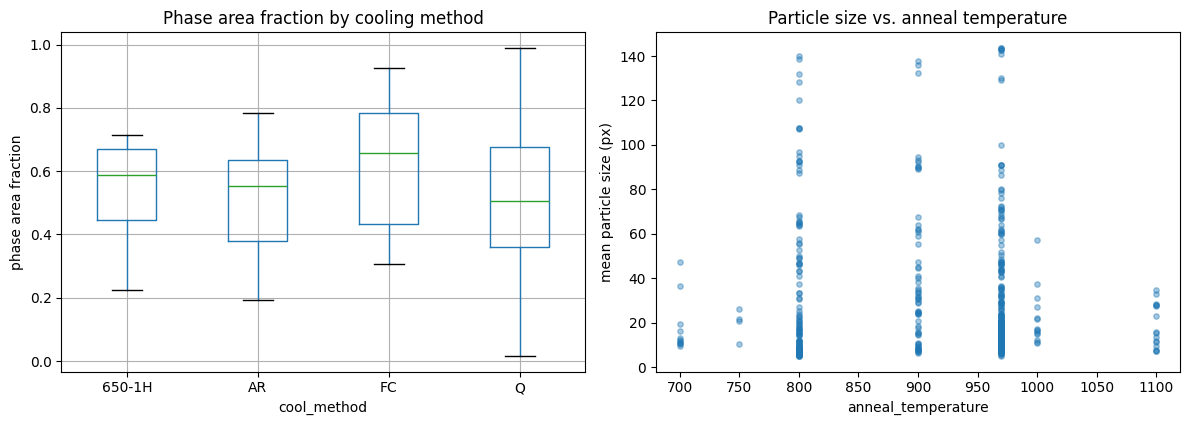

                           phase_area_fraction  mean_particle_size_px  \
primary_microconstituent                                                
network                                  0.590                 24.504   
pearlite                                 0.516                 24.044   
pearlite+spheroidite                     0.572                 25.081   
pearlite+widmanstatten                   0.729                 67.014   
spheroidite                              0.484                 24.756   
spheroidite+widmanstatten                0.623                 31.235   

                           particle_count  glcm_contrast  
primary_microconstituent                                  
network                            11.683        701.144  
pearlite                           20.000       2056.044  
pearlite+spheroidite               19.750       1767.839  
pearlite+widmanstatten             13.000        521.968  
spheroidite                        32.000        992.959  
sp

In [22]:
# Correlate features against process metadata (only for the 598 labeled/metadata rows)
merged = meta.merge(features_df, left_on=meta['cropped_path'].apply(lambda p: os.path.basename(p)), right_on='filename')

fig, axes = plt.subplots(1,2, figsize=(12,4.5))
merged.boxplot(column='phase_area_fraction', by='cool_method', ax=axes[0])
axes[0].set_title('Phase area fraction by cooling method'); axes[0].set_xlabel('cool_method'); axes[0].set_ylabel('phase area fraction')

axes[1].scatter(merged['anneal_temperature'], merged['mean_particle_size_px'], alpha=0.4, s=15)
axes[1].set_xlabel('anneal_temperature'); axes[1].set_ylabel('mean particle size (px)')
axes[1].set_title('Particle size vs. anneal temperature')

plt.suptitle('')
plt.tight_layout(); plt.show()

print(merged.groupby('primary_microconstituent')[['phase_area_fraction','mean_particle_size_px','particle_count','glcm_contrast']].mean().round(3))


## 9. End-to-End Inference Pipeline

Chains everything above into one function: give it the path to a brand-new micrograph, and it returns the segmentation, the predicted class, and the 4 quantitative parameters.

In [23]:
def analyze_micrograph(image_path, size=IMG_SIZE):
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    gray_resized = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    x = (gray_resized.astype('float32')/255.0)[None, ..., None]

    # Stage 3: U-Net segmentation
    pred_mask = (unet.predict(x, verbose=0)[0,...,0] > 0.5).astype('uint8')

    # Stage 4: CNN classification
    class_probs = clf.predict(x, verbose=0)[0]
    pred_class = le.classes_[class_probs.argmax()]
    confidence = float(class_probs.max())

    # Stage 5: quantitative features (measured on the model's own predicted mask)
    feats = extract_features(gray_resized, pred_mask)

    return {
        'image': os.path.basename(image_path),
        'predicted_class': pred_class,
        'confidence': round(confidence, 3),
        'predicted_mask': pred_mask,
        'input_image': gray_resized,
        'features': feats,
    }

def show_analysis(result):
    fig, axes = plt.subplots(1,2, figsize=(7,3.5))
    axes[0].imshow(result['input_image'], cmap='gray'); axes[0].set_title(result['image']); axes[0].axis('off')
    axes[1].imshow(result['predicted_mask'], cmap='gray'); axes[1].set_title('predicted phase mask'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
    print(f"Predicted class : {result['predicted_class']}  (confidence {result['confidence']:.1%})")
    for k,v in result['features'].items():
        print(f"  {k:22s}: {v}")


--- ./data/For Training/Cropped/Croppedmicrograph1707.png (true label: spheroidite) ---


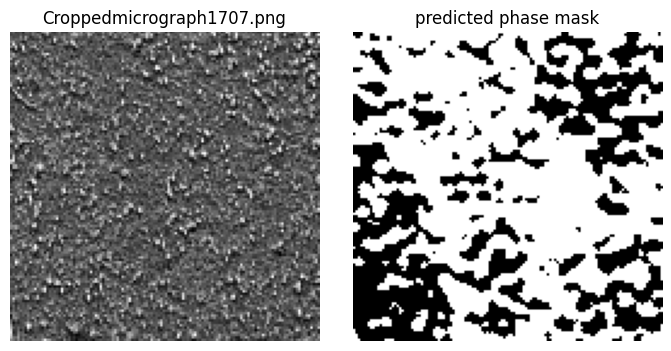

Predicted class : spheroidite+widmanstatten  (confidence 33.6%)
  phase_area_fraction   : 0.6478
  mean_particle_size_px : 9.9
  particle_count        : 26
  particle_density      : 0.001587
  glcm_contrast         : 2201.44



--- ./data/For Training/Cropped/Croppedmicrograph1150.png (true label: spheroidite) ---


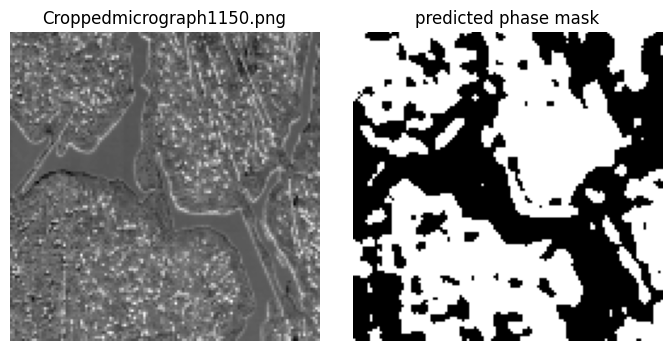

Predicted class : spheroidite  (confidence 32.9%)
  phase_area_fraction   : 0.5366
  mean_particle_size_px : 12.45
  particle_count        : 27
  particle_density      : 0.001648
  glcm_contrast         : 588.17



--- ./data/For Training/Cropped/Croppedmicrograph1197.png (true label: spheroidite) ---


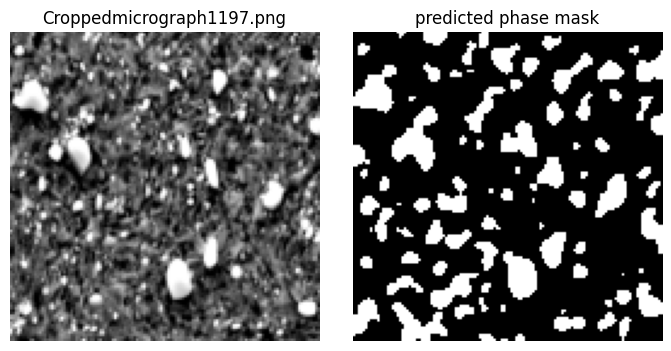

Predicted class : spheroidite  (confidence 34.3%)
  phase_area_fraction   : 0.2366
  mean_particle_size_px : 7.0
  particle_count        : 78
  particle_density      : 0.004761
  glcm_contrast         : 1656.0



In [24]:
# Demo on 3 held-out test images the models never trained on (re-derive the same test split)
_, meta_te = train_test_split(meta, test_size=0.2, random_state=SEED, stratify=meta['label_id'])
for _, row in meta_te.sample(3, random_state=SEED).iterrows():
    result = analyze_micrograph(row['cropped_path'])
    print(f"--- {row['cropped_path']} (true label: {row['primary_microconstituent']}) ---")
    show_analysis(result)
    print()


## 10. Performance Summary

In [25]:
summary = pd.DataFrame([
    {'Model': 'U-Net (segmentation)', 'Metric': 'Mean IoU vs. pseudo-mask', 'Value': round(float(val_iou.mean()),4)},
    {'Model': 'U-Net (segmentation)', 'Metric': 'Mean Dice vs. pseudo-mask', 'Value': round(float(val_dice.mean()),4)},
    {'Model': 'U-Net (segmentation)', 'Metric': 'Pixel accuracy vs. pseudo-mask', 'Value': round(float(history_unet.history['val_accuracy'][-1]),4)},
    {'Model': 'CNN (classification)', 'Metric': 'Test accuracy (real labels)', 'Value': round(float(test_acc),4)},
    {'Model': 'CNN (classification)', 'Metric': 'Test F1 macro (real labels)', 'Value': round(float(test_f1_macro),4)},
    {'Model': 'CNN (classification)', 'Metric': 'Test F1 weighted (real labels)', 'Value': round(float(test_f1_weighted),4)},
])
summary


,Model,Metric,Value
0,U-Net (segmentation),Mean IoU vs. pseudo-mask,0.7508
1,U-Net (segmentation),Mean Dice vs. pseudo-mask,0.8504
2,U-Net (segmentation),Pixel accuracy vs. pseudo-mask,0.8531
3,CNN (classification),Test accuracy (real labels),0.6000
4,CNN (classification),Test F1 macro (real labels),0.1544
5,CNN (classification),Test F1 weighted (real labels),0.4882


## 11. Limitations & Future Work

- **No independently annotated segmentation ground truth.** U-Net Dice/IoU scores measure agreement with classical-threshold pseudo-masks, not verified phase boundaries. Routing verified masks through `./masks_verified/` (Section 5) and retraining closes this gap incrementally.
- **Severe class imbalance** in the classifier (`spheroidite`=372 vs `pearlite+widmanstatten`=5). Macro-F1 is reported alongside accuracy specifically so this isn't hidden; rare-class metrics should be treated as high-variance until more examples are collected.
- **Small dataset for a segmentation task** (961 unlabeled + 598 labeled images) -- this is exactly why the architecture choice was CNN-based (U-Net) rather than a transformer segmenter, which would need substantially more data or heavy pretraining to compete.
- **Otsu thresholding is a global, single-value method.** It works well when a micrograph has two cleanly separable intensity populations, and degrades on more complex multi-phase or low-contrast images -- another reason human verification (Stage 2) matters before trusting the pseudo-masks fully.
- **Next steps:** verify a meaningful subset of masks by hand, consider multi-class segmentation (more than 2 phases) if the verified masks support it, and evaluate a pretrained encoder (e.g. ImageNet-pretrained ResNet as the U-Net encoder) if more labeled data becomes available.


## 12. Conclusion

This notebook builds a full pipeline that takes a **new, unseen ultra-high-carbon-steel micrograph** and returns: a pixel-level phase segmentation (U-Net), a predicted microconstituent class (CNN, trained on real expert labels), and 4 quantitative microstructural parameters computed automatically from the segmentation. The segmentation and classification stages are evaluated separately and honestly against the ground truth each actually has available -- real labels for classification, pseudo-labels (with a human-verification path) for segmentation -- rather than blending the two into a single misleading accuracy figure.